In [1]:
import numpy as np

In [2]:
import json
with open('../artifacts/kaggle.json','r') as file:
    data=json.load(file)

In [3]:
data

{'username': 'dilurathnayaka', 'key': 'c54bb587c88812524100e238104bc568'}

In [4]:
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import os

In [6]:
os.environ['KAGGLE_USERNAME']=data['username']
os.environ['KAGGLE_KEY']=data['key']

In [7]:
from kaggle.api.kaggle_api_extended import KaggleApi

In [8]:
api=KaggleApi()

In [9]:
api.authenticate()

In [10]:
api.dataset_download_files('dineshpiyasamara/sentiment-analysis-dataset',path='../artifacts')

Dataset URL: https://www.kaggle.com/datasets/dineshpiyasamara/sentiment-analysis-dataset


ConnectionError: HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/datasets.DatasetApiService/DownloadDataset (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002A964A51FD0>: Failed to resolve 'api.kaggle.com' ([Errno 11001] getaddrinfo failed)"))

In [ ]:
#unzip file 

In [12]:
import zipfile
with zipfile.ZipFile('../artifacts/sentiment-analysis-dataset.zip','r') as zip_ref:
    zip_ref.extractall('../artifacts/')


In [13]:
import pandas as pd

In [14]:
data=pd.read_csv('../artifacts/sentiment_analysis.csv')

In [15]:
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


# Data preprocessing 

In [16]:
data.shape

(7920, 3)

In [17]:
data.duplicated().sum()

np.int64(0)

In [18]:
data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

# Text preprocessing

In [19]:
import re
import string

In [20]:
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


In [21]:
data["tweet"]=data["tweet"].str.replace(r"http\S+|www\S+","",regex=True)

In [22]:
data["tweet"].head()

0    #fingerprint #Pregnancy Test  #android #apps #...
1    Finally a transparant silicon case ^^ Thanks t...
2    We love this! Would you go? #talk #makememorie...
3    I'm wired I know I'm George I was made that wa...
4    What amazing service! Apple won't even talk to...
Name: tweet, dtype: object

In [23]:
string.punctuation


'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [24]:
data["tweet"]=data["tweet"].str.replace(r"[^\w\s]","",regex=True)

In [25]:
data.head()

,id,label,tweet
0,1,0,fingerprint Pregnancy Test android apps beaut...
1,2,0,Finally a transparant silicon case Thanks to ...
2,3,0,We love this Would you go talk makememories un...
3,4,0,Im wired I know Im George I was made that way ...
4,5,1,What amazing service Apple wont even talk to m...


In [26]:
data.tail()

,id,label,tweet
7915,7916,0,Live out loud lol liveoutloud selfie smile son...
7916,7917,0,We would like to wish you an amazing day Make ...
7917,7918,0,Helping my lovely 90 year old neighbor with he...
7918,7919,0,Finally got my smart pocket wifi stay connecte...
7919,7920,0,Apple Barcelona Apple Store BCN Barcelona trav...


In [27]:
data["tweet"]=data["tweet"].str.replace(r"\d+","",regex=True)

In [28]:
data.tail()



,id,label,tweet
7915,7916,0,Live out loud lol liveoutloud selfie smile son...
7916,7917,0,We would like to wish you an amazing day Make ...
7917,7918,0,Helping my lovely year old neighbor with her ...
7918,7919,0,Finally got my smart pocket wifi stay connecte...
7919,7920,0,Apple Barcelona Apple Store BCN Barcelona trav...


Remove stopwords

In [29]:
!pip install  nltk


Defaulting to user installation because normal site-packages is not writeable


In [30]:
import nltk

In [31]:
nltk.download('stopwords')

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [32]:
nltk.download('punkt')

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [33]:
from nltk.corpus import stopwords

In [34]:
stop_words=set(stopwords.words('english'))

In [35]:
stop_words


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [36]:
data['stopwords_found']=data['tweet'].apply(
    lambda x: [word for word in str(x).split() if word.lower() in stop_words]
)

In [37]:
data['stopwords_found'].head()

0                                                   []
1                                       [a, to, my, S]
2                                      [We, this, you]
3                                    [I, I, was, that]
4    [What, to, me, about, a, I, have, I, them, for...
Name: stopwords_found, dtype: object

In [38]:
data['tweet'].apply(
    lambda x: ' '.join([word for word in str(x).split() if word.lower() not in stop_words])
)

0       fingerprint Pregnancy Test android apps beauti...
1       Finally transparant silicon case Thanks uncle ...
2       love Would go talk makememories unplug relax i...
3       Im wired know Im George made way iphone cute d...
4       amazing service Apple wont even talk question ...
                              ...                        
7915    Live loud lol liveoutloud selfie smile sony mu...
7916    would like wish amazing day Make every minute ...
7917    Helping lovely year old neighbor iPad morning ...
7918    Finally got smart pocket wifi stay connected a...
7919    Apple Barcelona Apple Store BCN Barcelona trav...
Name: tweet, Length: 7920, dtype: object

In [39]:
data.head()

,id,label,tweet,stopwords_found
0,1,0,fingerprint Pregnancy Test android apps beaut...,[]
1,2,0,Finally a transparant silicon case Thanks to ...,"[a, to, my, S]"
2,3,0,We love this Would you go talk makememories un...,"[We, this, you]"
3,4,0,Im wired I know Im George I was made that way ...,"[I, I, was, that]"
4,5,1,What amazing service Apple wont even talk to m...,"[What, to, me, about, a, I, have, I, them, for..."


 Stemming

In [40]:
from nltk.stem import PorterStemmer


In [41]:
stemmer=PorterStemmer()

In [42]:
data['tweet'].apply(
    lambda x: ' '.join(stemmer.stem(word) for word in str(x).split())
)

0       fingerprint pregnanc test android app beauti c...
1       final a transpar silicon case thank to my uncl...
2       we love thi would you go talk makememori unplu...
3       im wire i know im georg i wa made that way iph...
4       what amaz servic appl wont even talk to me abo...
                              ...                        
7915    live out loud lol liveoutloud selfi smile soni...
7916    we would like to wish you an amaz day make eve...
7917    help my love year old neighbor with her ipad t...
7918    final got my smart pocket wifi stay connect an...
7919    appl barcelona appl store bcn barcelona travel...
Name: tweet, Length: 7920, dtype: object

In [43]:
data['tweet'].head()

0    fingerprint Pregnancy Test  android apps beaut...
1    Finally a transparant silicon case  Thanks to ...
2    We love this Would you go talk makememories un...
3    Im wired I know Im George I was made that way ...
4    What amazing service Apple wont even talk to m...
Name: tweet, dtype: object

  # make Vocabluary 

In [62]:
from collections  import Counter
vocab=Counter()

In [63]:
vocab

Counter()

In [67]:
for sentence in data['tweet']:
    vocab.update(sentence.split())


In [68]:
vocab

Counter({'iphone': 2591,
         'my': 1857,
         'to': 1822,
         'apple': 1791,
         'I': 1771,
         'the': 1719,
         'a': 1291,
         'iPhone': 1218,
         'and': 1187,
         'for': 1033,
         'Apple': 1007,
         'samsung': 928,
         'phone': 883,
         'new': 860,
         'it': 853,
         'is': 832,
         'you': 822,
         'me': 777,
         'on': 692,
         'of': 691,
         'in': 658,
         'with': 561,
         'sony': 550,
         'Samsung': 466,
         'this': 440,
         'have': 408,
         'life': 392,
         'My': 389,
         'like': 379,
         'at': 368,
         'RT': 355,
         'an': 341,
         'your': 328,
         'so': 325,
         'now': 317,
         'FOLLOW': 312,
         'cute': 310,
         'day': 307,
         'that': 305,
         'just': 299,
         'ipad': 294,
         'Gain': 294,
         'all': 291,
         'photography': 285,
         'instagram': 280,
         'an

In [69]:
len(vocab)

21268

In [71]:
data.shape

(7920, 4)

In [72]:
tokens=[key for key in vocab if vocab[key]>10 ]

In [73]:
tokens

['android',
 'apps',
 'beautiful',
 'cute',
 'health',
 'igers',
 'iphoneonly',
 'iphonesia',
 'iphone',
 'Finally',
 'a',
 'case',
 'Thanks',
 'to',
 'my',
 'yay',
 'Sony',
 'Xperia',
 'S',
 'We',
 'love',
 'this',
 'you',
 'go',
 'talk',
 'relax',
 'smartphone',
 'wifi',
 'connect',
 'Im',
 'I',
 'know',
 'was',
 'made',
 'that',
 'way',
 'home',
 'What',
 'amazing',
 'service',
 'Apple',
 'wont',
 'even',
 'me',
 'about',
 'have',
 'pay',
 'them',
 'for',
 'their',
 'stupid',
 'support',
 'iPhone',
 'software',
 'update',
 'fucked',
 'up',
 'phone',
 'big',
 'time',
 'Stupid',
 'iPhones',
 'Happy',
 'us',
 'instapic',
 'instadaily',
 'sony',
 'xperia',
 'New',
 'C',
 'charger',
 'cable',
 'Amazon',
 'Year',
 'technology',
 'iPhoneX',
 'shopping',
 'again',
 'music',
 'likeforlike',
 'Photo',
 'fun',
 'selfie',
 'water',
 'camera',
 'picoftheday',
 'sun',
 'instagood',
 'boy',
 'apple',
 'when',
 'make',
 'new',
 'ipod',
 'dont',
 'it',
 'color',
 'or',
 'not',
 'every',
 'Not',
 'bu

In [74]:
len(tokens)

1393

In [75]:
def save_vocabulary(lines,filename):
    data='\n'.join(lines)
    file=open(filename,'w',encoding="utf-8")
    file.write(data)
    file.close()

In [79]:
save_vocabulary(tokens,'vocabulary.txt')

# Divide dataset

In [80]:
data.head()

,id,label,tweet,stopwords_found
0,1,0,fingerprint Pregnancy Test android apps beaut...,[]
1,2,0,Finally a transparant silicon case Thanks to ...,"[a, to, my, S]"
2,3,0,We love this Would you go talk makememories un...,"[We, this, you]"
3,4,0,Im wired I know Im George I was made that way ...,"[I, I, was, that]"
4,5,1,What amazing service Apple wont even talk to m...,"[What, to, me, about, a, I, have, I, them, for..."


In [81]:
x=data['tweet']
y=data['label']

In [82]:
y


0       0
1       0
2       0
3       0
4       1
       ..
7915    0
7916    0
7917    0
7918    0
7919    0
Name: label, Length: 7920, dtype: int64

In [83]:
x

0       fingerprint Pregnancy Test  android apps beaut...
1       Finally a transparant silicon case  Thanks to ...
2       We love this Would you go talk makememories un...
3       Im wired I know Im George I was made that way ...
4       What amazing service Apple wont even talk to m...
                              ...                        
7915    Live out loud lol liveoutloud selfie smile son...
7916    We would like to wish you an amazing day Make ...
7917    Helping my lovely  year old neighbor with her ...
7918    Finally got my smart pocket wifi stay connecte...
7919    Apple Barcelona Apple Store BCN Barcelona trav...
Name: tweet, Length: 7920, dtype: object

In [90]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [98]:
from sklearn.model_selection import train_test_split

In [151]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [152]:
x_train.shape


(6336,)

In [153]:
x_test.shape

(1584,)

In [154]:
y_test

4896    0
7539    1
1677    0
1964    0
3025    0
       ..
1419    0
3939    0
7834    1
5137    1
4434    0
Name: label, Length: 1584, dtype: int64

In [155]:
y_train

4252    0
4428    0
7374    1
1410    0
7896    1
       ..
5226    0
5390    1
860     0
7603    0
7270    1
Name: label, Length: 6336, dtype: int64

In [156]:
len(y_train)

6336

In [157]:
x_train

4252    Cool Car wash idea TheIsland BankHolidayMonday...
4428    Photo th Birthday to the Sony walkman thinkgee...
7374    iPads are the biggest pile of fucking  on the ...
1410    Yearbook Hmmmmm instagram instagood together f...
7896    So pissed Macbook crashes Apple Company does n...
                              ...                        
5226    Shana tova Jewish newyear everyone may your ne...
5390    Im so sick of buying new cell phone chargers a...
860     it Want it Have it Download the free iPhone ap...
7603    Photo nikosx iphone beach holiday bw iphone bl...
7270    Just got an iPhone S  hehe iPhone apple new fi...
Name: tweet, Length: 6336, dtype: object

In [158]:
len(x_train)

6336

In [159]:
x_test

4896    Photo cause we both dressed up today  boyfrien...
7539    skullcandy your product is brutal  headphone a...
1677    Sunset Today in Zeeland  Samsung Mobile S sams...
1964    God  it playstation share feature Cutting my c...
3025    Awe hes da bestest  boyfriend him iloveyou cut...
                              ...                        
1419    Who is  today Meee Birthday to me cake sweet s...
3939    arualcampbell as if you you do nothing but rea...
7834    using new macbookpro for last  days  battery b...
5137    robertwindon I cant fix junk apple power cords...
4434    Using my zoooom zoom lens iphone dogwalks trev...
Name: tweet, Length: 1584, dtype: object

# Vectorization

In [160]:
import numpy as np

def vectorizer(ds, vocabulary):

    vectorized_lst = []   # me line eka add karanna

    for sentence in ds:

        sentence_lst = np.zeros(len(vocabulary))

        for i in range(len(vocabulary)):

            if vocabulary[i] in sentence.split():
                sentence_lst[i] = 1

        vectorized_lst.append(sentence_lst)

    vectorized_lst_new = np.asarray(vectorized_lst, dtype=np.float32)

    return vectorized_lst_new


In [161]:
vectorized_x_train=vectorizer(x_train,tokens)

In [162]:
vectorized_x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6336, 1393), dtype=float32)

In [163]:
vectorized_x_test=vectorizer(x_test,tokens)

In [164]:
vectorized_x_train.shape[0]

6336

In [165]:
len(y_train)

6336

In [166]:
# balance nthi data set ekkda blnw 0,1 

In [167]:
y_train.value_counts()

label
0    4742
1    1594
Name: count, dtype: int64

In [168]:
import matplotlib.pyplot as plt

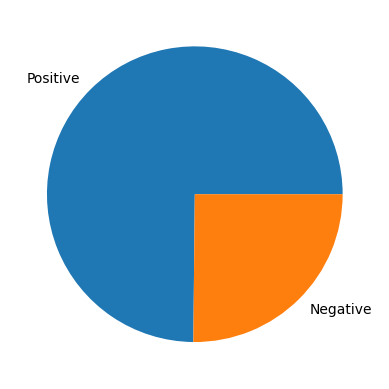

In [169]:
plt.pie(
    np.array([y_train.value_counts()[0], y_train.value_counts()[1]]),
    labels=['Positive', 'Negative']
)

plt.show()

# Handle inbalance dataset

In [170]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [171]:
from imblearn.over_sampling import SMOTE

In [172]:
print(vectorized_x_train.shape)
print(y_train.shape)

(6336, 1393)
(6336,)


In [173]:
smote=SMOTE()

In [174]:
vectorized_x_train_smote, y_train_smote = smote.fit_resample(vectorized_x_train, y_train)

print(vectorized_x_train_smote.shape, y_train_smote.shape)

(9484, 1393) (9484,)


In [175]:
y_train_smote.value_counts()

label
0    4742
1    4742
Name: count, dtype: int64

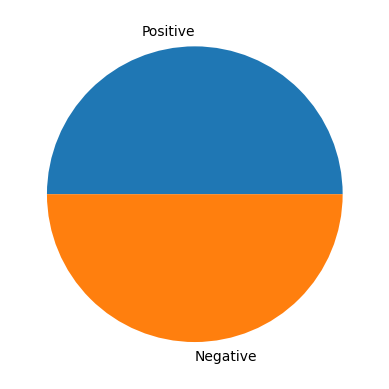

In [176]:
plt.pie(
    np.array([y_train_smote.value_counts()[0], y_train_smote.value_counts()[1]]),
    labels=['Positive', 'Negative']
)

plt.show()

In [177]:
vectorized_x_train_smote

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(9484, 1393), dtype=float32)

In [178]:
y_train_smote

0       0
1       0
2       1
3       0
4       1
       ..
9479    1
9480    1
9481    1
9482    1
9483    1
Name: label, Length: 9484, dtype: int64

In [179]:
vectorized_x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1584, 1393), dtype=float32)

In [180]:
y_test

4896    0
7539    1
1677    0
1964    0
3025    0
       ..
1419    0
3939    0
7834    1
5137    1
4434    0
Name: label, Length: 1584, dtype: int64

# Model Training and Evalution

In [189]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [204]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score


In [205]:
def training_scores(y_act,y_pred):
    acc=round(accuracy_score(y_act,y_pred),3)
    pr=round(accuracy_score(y_act,y_pred),3)
    rec=round(recall_score(y_act,y_pred),3)
    f1=round(f1_score(y_act,y_pred),3)
    print(f'Training Scores:\n\tAccuracy = {acc}\n\tPrecision= {pr}\n\tRecall ={rec}\n\tF1-Score={f1}')


def validation_scores(y_act,y_pred):
    acc=round(accuracy_score(y_act,y_pred),3)
    pr=round(precision_score(y_act,y_pred),3)
    rec=round(recall_score(y_act,y_pred),3)
    f1=round(f1_score(y_act,y_pred),3)
    print(f'Testing Scores:\n\tAccuracy ={acc}\n\tPrecision = {pr}\n\tRecall ={rec}\n\tF1-Score={f1}' )


# Logistic Regression

In [206]:
model1=LogisticRegression()

In [217]:
model1.fit(vectorized_x_train_smote,y_train_smote)

y_train_pred=model1.predict(vectorized_x_train_smote)

y_test_pred=model1.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)

validation_scores(y_test,y_test_pred)


Training Scores:
	Accuracy = 0.941
	Precision= 0.941
	Recall =0.968
	F1-Score=0.942
Testing Scores:
	Accuracy =0.867
	Precision = 0.717
	Recall =0.85
	F1-Score=0.778


# Naive Bayes

In [219]:
model2=MultinomialNB()

model2.fit(vectorized_x_train_smote,y_train_smote)

y_train_pred=model2.predict(vectorized_x_train_smote)

y_test_pred=model2.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)

validation_scores(y_test,y_test_pred)


Training Scores:
	Accuracy = 0.898
	Precision= 0.898
	Recall =0.966
	F1-Score=0.904
Testing Scores:
	Accuracy =0.869
	Precision = 0.685
	Recall =0.961
	F1-Score=0.8


# Decision Tree

In [220]:
model3=DecisionTreeClassifier()

model3.fit(vectorized_x_train_smote,y_train_smote)

y_train_pred=model3.predict(vectorized_x_train_smote)

y_test_pred=model3.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)

validation_scores(y_test,y_test_pred)


Training Scores:
	Accuracy = 1.0
	Precision= 1.0
	Recall =0.999
	F1-Score=1.0
Testing Scores:
	Accuracy =0.799
	Precision = 0.64
	Recall =0.602
	F1-Score=0.621


# Random Forest

In [221]:
model4=RandomForestClassifier()

model4.fit(vectorized_x_train_smote,y_train_smote)

y_train_pred=model4.predict(vectorized_x_train_smote)

y_test_pred=model4.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)

validation_scores(y_test,y_test_pred)


Training Scores:
	Accuracy = 1.0
	Precision= 1.0
	Recall =1.0
	F1-Score=1.0
Testing Scores:
	Accuracy =0.863
	Precision = 0.769
	Recall =0.711
	F1-Score=0.739


# Support Vector Machine(svm)

In [222]:
model5=SVC()

model5.fit(vectorized_x_train_smote,y_train_smote)

y_train_pred=model5.predict(vectorized_x_train_smote)

y_test_pred=model5.predict(vectorized_x_test)

training_scores(y_train_smote,y_train_pred)

validation_scores(y_test,y_test_pred)


Training Scores:
	Accuracy = 0.986
	Precision= 0.986
	Recall =0.995
	F1-Score=0.986
Testing Scores:
	Accuracy =0.881
	Precision = 0.762
	Recall =0.817
	F1-Score=0.789


In [223]:
import pickle 

In [225]:
with open('model.pkl','wb') as file:
    pickle.dump(model5,file)